# Data Preprocessing - Water Potability

Mục tiêu:
- Kiểm tra outlier.
- Tách feature và target.
- Kiểm tra missing values.
- Chia dữ liệu Train/Test.
- Xây dựng preprocessing pipeline.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


possible_paths = [
    Path("../data/water_potability.csv"),
    Path("ai-models/data/water_potability.csv"),
    Path("../ai-models/data/water_potability.csv"),
]

data_path = next(
    (
        path
        for path in possible_paths
        if path.exists()
    ),
    None,
)

if data_path is None:
    raise FileNotFoundError(
        "Không tìm thấy water_potability.csv"
    )


df = pd.read_csv(data_path)


TARGET_COLUMN = "Potability"

FEATURE_COLUMNS = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity",
]

TEST_SIZE = 0.20
RANDOM_STATE = 42

print("Dataset path:", data_path.resolve())
print("Dataset shape:", df.shape)

Dataset path: F:\4\Hoc may co ban\WaterQualityProject\ai-models\data\water_potability.csv
Dataset shape: (3276, 10)


## 1. Kiểm tra Outlier

Sử dụng phương pháp IQR (Interquartile Range) để kiểm tra các giá trị
ngoại lai trong 9 đặc trưng đầu vào.

Một giá trị được xem là outlier khi:

- Nhỏ hơn `Q1 - 1.5 × IQR`
- Hoặc lớn hơn `Q3 + 1.5 × IQR`

Trong đó:

`IQR = Q3 - Q1`

Ngoài việc thống kê số lượng outlier, boxplot được sử dụng để trực quan hóa
phân bố của từng đặc trưng.

           Feature  Outlier_Count  Outlier_Percent
0         Hardness             83             2.53
1      Chloramines             61             1.86
2           Solids             47             1.43
3               ph             46             1.65
4          Sulfate             41             1.64
5  Trihalomethanes             33             1.06
6   Organic_carbon             25             0.76
7        Turbidity             19             0.58
8     Conductivity             11             0.34


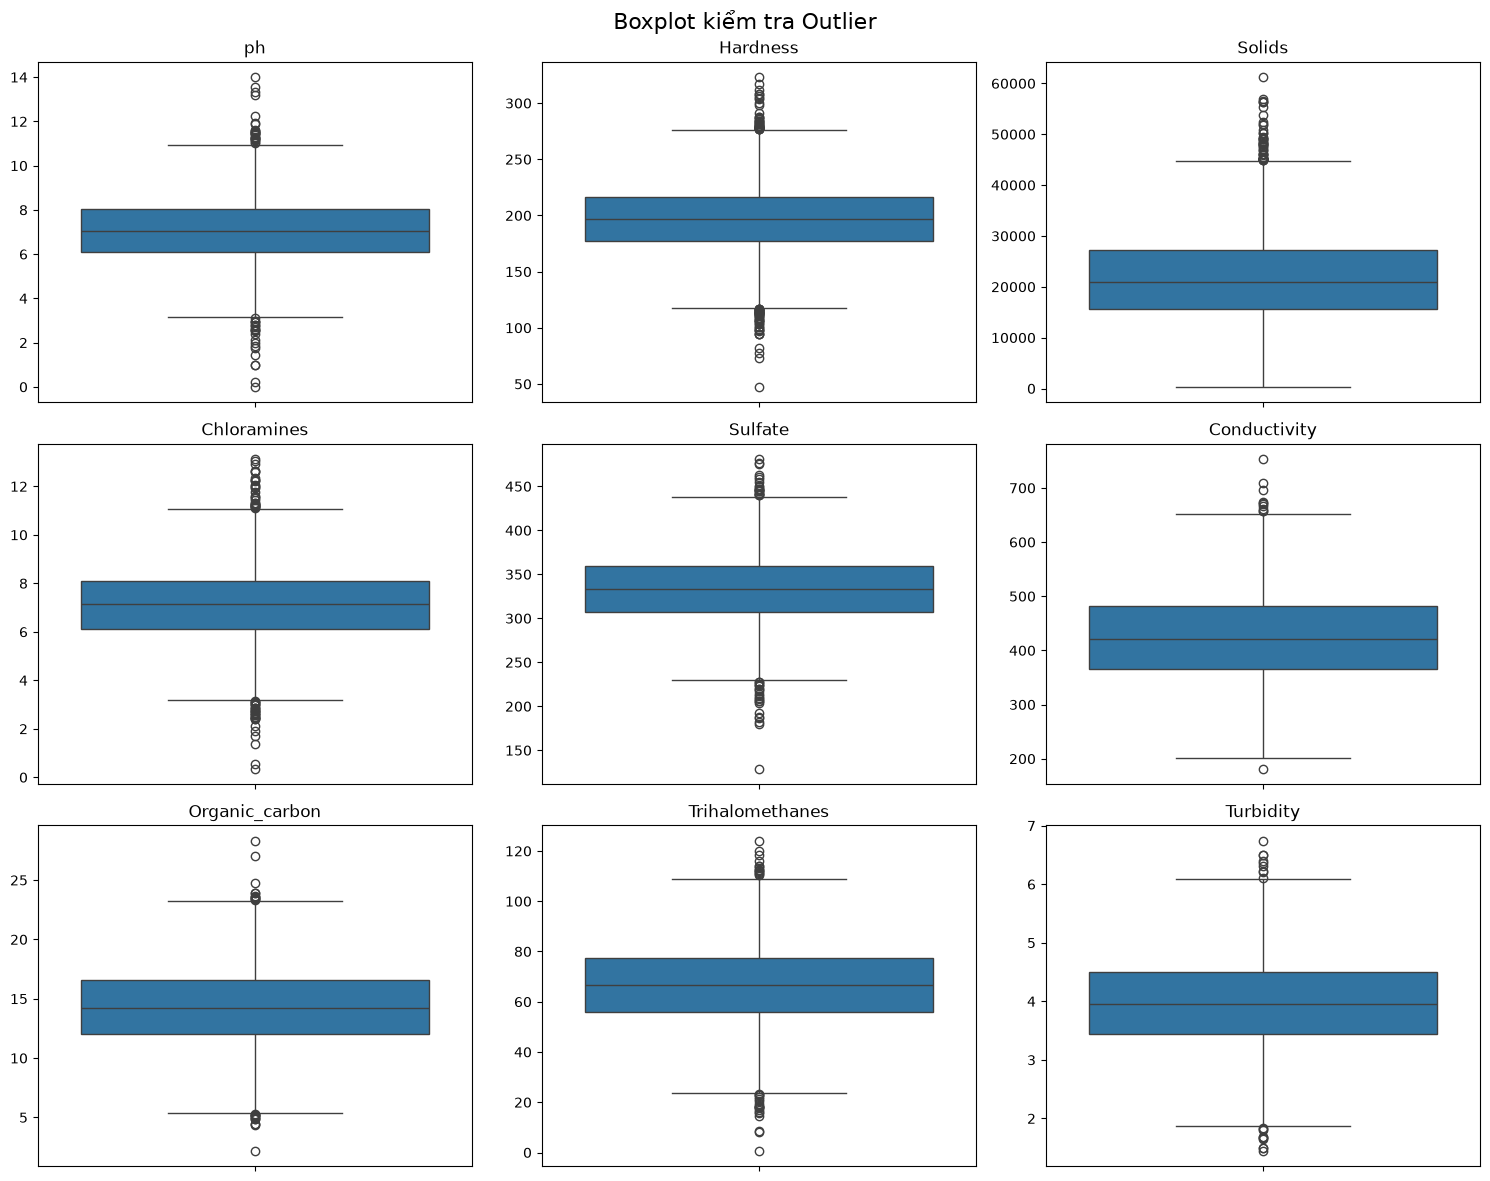

In [2]:
outlier_results = []


for feature in FEATURE_COLUMNS:

    series = df[feature].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound)
        |
        (series > upper_bound)
    ).sum()

    outlier_percent = (
        outlier_count
        / len(series)
        * 100
    )

    outlier_results.append({
        "Feature": feature,
        "Outlier_Count": outlier_count,
        "Outlier_Percent": outlier_percent,
    })


outlier_summary = (
    pd.DataFrame(outlier_results)
    .sort_values(
        "Outlier_Count",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    outlier_summary.round(2)
)


fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12),
)

for ax, feature in zip(
    axes.flatten(),
    FEATURE_COLUMNS,
):

    sns.boxplot(
        y=df[feature],
        ax=ax,
    )

    ax.set_title(feature)
    ax.set_ylabel("")


plt.suptitle(
    "Boxplot kiểm tra Outlier",
    fontsize=16,
)

plt.tight_layout()
plt.show()

### Nhận xét

Phương pháp IQR cho thấy cả 9 đặc trưng đều xuất hiện một số giá trị
ngoại lai.

Trong đó:

- `Hardness` có số lượng outlier cao nhất.
- Tiếp theo là `Chloramines`, `Solids`, `ph` và `Sulfate`.
- Các đặc trưng còn lại có số lượng outlier thấp hơn.

Tuy nhiên, tỷ lệ outlier của từng đặc trưng tương đối nhỏ.

Các giá trị này chưa thể khẳng định là dữ liệu sai vì chúng có thể phản ánh
những mẫu nước có đặc tính hóa học khác biệt trong thực tế.

### Hướng xử lý

Không loại bỏ các giá trị ngoại lai nhằm tránh làm mất thông tin và giảm
số lượng mẫu trong dataset.

Đối với Logistic Regression và SVM, các đặc trưng sẽ được chuẩn hóa bằng
`StandardScaler` trong preprocessing pipeline.

## 2. Feature, Target và Missing Values

Dataset được tách thành:

- `X`: 9 đặc trưng đầu vào dùng để huấn luyện mô hình.
- `y`: biến mục tiêu `Potability`.

Ý nghĩa của biến mục tiêu:

- `Potability = 0`: Nước không uống được.
- `Potability = 1`: Nước uống được.

Tiếp theo, kiểm tra missing values trong các đặc trưng đầu vào và
biến mục tiêu.

In [3]:
X = df[FEATURE_COLUMNS].copy()

y = df[TARGET_COLUMN].copy()



missing_summary = pd.DataFrame({
    "Missing_Count": X.isnull().sum(),

    "Missing_Percent": (
        X.isnull().mean()
        * 100
    ).round(2),
})


missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]


print("X shape:", X.shape)
print("y shape:", y.shape)


print(
    "Target values:",
    sorted(y.unique())
)


print(
    "Missing trong target:",
    y.isnull().sum(),
)


print("\nMissing values:")

print(
    missing_summary
)

X shape: (3276, 9)
y shape: (3276,)
Target values: [np.int64(0), np.int64(1)]
Missing trong target: 0

Missing values:
                 Missing_Count  Missing_Percent
ph                         491            14.99
Sulfate                    781            23.84
Trihalomethanes            162             4.95


### Nhận xét

Missing values xuất hiện ở ba đặc trưng:

- `ph`
- `Sulfate`
- `Trihalomethanes`

Biến mục tiêu `Potability` không có missing value.

Các giá trị thiếu chỉ xuất hiện ở biến đầu vào, vì vậy các mẫu này vẫn
có thể được sử dụng để huấn luyện mô hình sau khi thực hiện bước xử lý
missing values.

### Hướng xử lý

Không loại bỏ các dòng có giá trị thiếu nhằm giữ lại tối đa số lượng mẫu
trong dataset.

Trong preprocessing pipeline, sử dụng
`SimpleImputer(strategy="median")` để thay thế các giá trị thiếu.

Median được lựa chọn vì ít bị ảnh hưởng bởi các giá trị ngoại lai hơn mean.

Bộ imputer chỉ được fit trên dữ liệu huấn luyện nhằm tránh
data leakage.

## 3. Train/Test Split

Dữ liệu được chia thành hai tập:

- 80% dữ liệu dùng để huấn luyện mô hình.
- 20% dữ liệu dùng để kiểm thử mô hình.

Sử dụng:

- `random_state=42` để đảm bảo khả năng tái lập kết quả.
- `stratify=y` để duy trì tỷ lệ hai lớp của `Potability`
  giữa tập Train và Test.

Tập Test được giữ riêng và không được sử dụng trong quá trình
tuning mô hình.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)


def class_distribution(series):

    count = (
        series
        .value_counts()
        .sort_index()
    )

    percent = (
        series
        .value_counts(
            normalize=True
        )
        .sort_index()
        .mul(100)
        .round(2)
    )

    return pd.DataFrame({
        "Count": count,
        "Percent": percent,
    })


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


train_test_overlap = len(
    X_train.index.intersection(
        X_test.index
    )
)

print(
    "Train/Test overlap:",
    train_test_overlap,
)



print("\nTraining set:")

print(
    class_distribution(
        y_train
    )
)


print("\nTest set:")

print(
    class_distribution(
        y_test
    )
)

X_train: (2620, 9)
X_test : (656, 9)
y_train: (2620,)
y_test : (656,)
Train/Test overlap: 0

Training set:
            Count  Percent
Potability                
0            1598    60.99
1            1022    39.01

Test set:
            Count  Percent
Potability                
0             400    60.98
1             256    39.02


### Nhận xét

Sau khi chia dữ liệu:

- Tập Train gồm 2620 mẫu.
- Tập Test gồm 656 mẫu.
- Hai tập không có mẫu bị trùng nhau (`Train/Test overlap = 0`).

Tỷ lệ hai lớp của `Potability` trong Train và Test gần như được giữ nguyên
nhờ sử dụng `stratify=y`.

Trong cả hai tập:

- Lớp `0` chiếm khoảng 61%.
- Lớp `1` chiếm khoảng 39%.

Như vậy lớp `0` có số lượng mẫu nhiều hơn lớp `1`, do đó khi đánh giá
mô hình không nên chỉ dựa vào Accuracy mà cần xem xét thêm Precision,
Recall, F1-score, ROC-AUC và Confusion Matrix.

Tập Test sẽ được giữ riêng và chỉ sử dụng trong bước đánh giá cuối cùng
ở `04_evaluate.ipynb`.

## 4. Preprocessing Pipeline

Đối với Logistic Regression và SVM, preprocessing pipeline gồm hai bước:

### Bước 1: Median Imputation

Sử dụng:

`SimpleImputer(strategy="median")`

để thay thế missing values của từng đặc trưng bằng giá trị trung vị
tương ứng.

Median được lựa chọn vì ít nhạy với các giá trị ngoại lai hơn mean.

### Bước 2: Standardization

Sử dụng:

`StandardScaler()`

để chuẩn hóa các đặc trưng về cùng thang đo.

Việc chuẩn hóa cần thiết đối với Logistic Regression và SVM vì các
mô hình này nhạy với độ lớn và thang đo của đặc trưng.

### Tránh Data Leakage

Preprocessing pipeline không được fit trên toàn bộ dataset trước khi
chia Train/Test.

Imputer và scaler chỉ được học từ dữ liệu Train trong quá trình
huấn luyện mô hình.

Tập Test chỉ được transform bằng các tham số đã học từ tập Train.

In [5]:
import sys


project_root = (
    data_path
    .resolve()
    .parents[2]
)

src_path = (
    project_root /
    "ai-models" /
    "src"
)

if str(src_path) not in sys.path:
    sys.path.insert(
        0,
        str(src_path)
    )


from preprocess import (
    build_scaled_preprocessor
)


shared_pipeline = (
    build_scaled_preprocessor()
)


print(
    "Import preprocess.py thành công"
)

print(
    "Pipeline dùng chung: "
    "Median Imputation -> StandardScaler"
)

Import preprocess.py thành công
Pipeline dùng chung: Median Imputation -> StandardScaler


## 5. Kết luận bước Preprocessing

Sau bước preprocessing, quy trình xử lý dữ liệu được xác định như sau:

- Dataset gồm 3276 mẫu.
- Sử dụng 9 đặc trưng đầu vào.
- Biến mục tiêu là `Potability`.
- Không loại bỏ các giá trị ngoại lai.
- Missing values xuất hiện ở `ph`, `Sulfate` và `Trihalomethanes`.
- Missing values được xử lý bằng median imputation.
- Dữ liệu được chia theo tỷ lệ 80% Train và 20% Test.
- `random_state=42` được sử dụng để đảm bảo khả năng tái lập kết quả.
- `stratify=y` được sử dụng để duy trì tỷ lệ lớp.
- Logistic Regression và SVM sử dụng `StandardScaler`.
- Imputer và scaler chỉ được fit trên dữ liệu huấn luyện để tránh data leakage.
- Tập Test được giữ riêng cho bước đánh giá cuối cùng.

Dữ liệu đã sẵn sàng cho bước huấn luyện mô hình trong
`03_train.ipynb`.